In [1]:
import os 
import umap 
import numpy as np            
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

/home/rachel/miniforge3/envs/mm-vae/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#config 
results_folder = '/home/rachel/Desktop/mm-vae results/multiregion_adbxd_cr/sampletest_singlegaussian_30perc' #'results_mmvae_multiregion_singlegaussianprior'  
dataset_abbrev = ['HC', 'PFC']  #['Geno', 'Physio']  
epoch = 50
latent_dim = 20 # 10 
hues =  ['cell_type', 'strain', 'encoder', '14-6-Bin'] # ['encoder', 'Diet']
random_state = 20

In [3]:
latent_space_1 = pd.read_csv(os.path.join(results_folder, f'latent_variables_epoch{epoch}_vae{dataset_abbrev[0]}.csv'), index_col=False)
latent_space_1

,LV1,LV2,LV3,LV4,LV5,LV6,LV7,LV8,LV9,LV10,...,cell_type_HC,SCBID_HC,MouseID_HC,Age_HC,Genotype_HC,CFM_14_5_snRNA_HC,14-6-residual_HC,14-6-Bin_HC,strain,encoder
0,0.841536,1.693594,-6.343078,-1.665026,0.126362,2.588125,1.652463,1.123457,-0.532597,-0.543050,...,glut,CK19012,1576,14,5,24.44,-0.673075,1,D2,HC
1,-0.059384,0.237056,-2.925490,2.762263,0.233917,0.148604,0.362642,-0.082269,0.258950,-0.028280,...,glut,CK19012,1576,14,5,24.44,-0.673075,1,D2,HC
2,-2.130337,0.456331,-0.139716,2.755518,-1.752198,1.643458,1.307314,1.224831,-0.050607,1.270410,...,glut,CK19012,1576,14,5,24.44,-0.673075,1,D2,HC
3,1.907925,-2.668868,3.625552,-1.803548,4.282400,-1.200847,-3.689881,2.040573,0.767839,2.981288,...,glut,CK19012,1576,14,5,24.44,-0.673075,1,D2,HC
4,-0.543092,0.367533,-0.652702,0.816206,-0.243537,0.905739,0.779527,-1.395027,-0.260186,-0.366116,...,glut,CK19012,1576,14,5,24.44,-0.673075,1,D2,HC
5,0.981291,-0.350953,1.137746,1.792957,-4.138418,-2.522564,0.678475,-1.607518,3.579844,-0.426684,...,Inhibitory,CK19012,1576,14,5,24.44,-0.673075,1,D2,HC
6,-1.872440,-0.815204,-1.757732,-1.423024,-1.791259,0.721876,1.697282,3.031338,-2.402030,-0.286272,...,glut,CK19012,1576,14,5,24.44,-0.673075,1,D2,HC
7,-0.172987,0.955735,-0.039486,1.156344,-0.543814,0.024374,1.571987,-0.355378,0.379467,0.636957,...,Oligodendrocytes,CK19012,1576,14,5,24.44,-0.673075,1,D2,HC
8,-5.063306,1.271600,2.808746,0.006518,1.988176,3.745919,-4.362633,-5.161782,-1.994533,-1.198194,...,Astrocytes,CK19012,1576,14,5,24.44,-0.673075,1,D2,HC
9,-0.956881,0.786577,0.012864,0.430783,-1.386675,-2.476841,1.672899,1.249863,-0.790347,-0.869080,...,glut,CK19012,1576,14,5,24.44,-0.673075,1,D2,HC


In [4]:
latent_space_2 = pd.read_csv(os.path.join(results_folder, f'latent_variables_epoch{epoch}_vae{dataset_abbrev[1]}.csv'), index_col=False)
latent_space_2

,LV1,LV2,LV3,LV4,LV5,LV6,LV7,LV8,LV9,LV10,...,cell_type_PFC,SCBID_PFC,MouseID_PFC,Age_PFC,Genotype_PFC,CFM_14_5_snRNA_PFC,14-6-residual_PFC,14-6-Bin_PFC,strain,encoder
0,3.692632,1.747841,-6.430323,-3.300739,1.016224,2.636380,2.105447,0.309797,-0.506138,-3.291794,...,Gaba,CK19106,1576,14,5,24.44,-0.552464,1,D2,PFC
1,0.196645,-0.079936,-1.466152,2.161351,1.326080,-1.431635,1.591158,-1.367593,-0.705805,0.948865,...,Glut,CK19106,1576,14,5,24.44,-0.552464,1,D2,PFC
2,-2.429143,1.551538,-1.133019,1.429003,-1.847169,0.644611,0.269128,1.239629,-1.101129,1.570941,...,Oligo,CK19106,1576,14,5,24.44,-0.552464,1,D2,PFC
3,-2.482409,1.160742,3.167697,-2.785500,5.962575,0.039448,-4.703037,-0.366494,1.002178,3.460355,...,Glut,CK19106,1576,14,5,24.44,-0.552464,1,D2,PFC
4,-0.419544,0.176405,-0.916975,0.846686,-0.965446,-0.173055,-0.247376,0.980697,-0.577402,0.245554,...,Gaba,CK19106,1576,14,5,24.44,-0.552464,1,D2,PFC
5,1.930488,0.620306,1.733218,2.670854,-2.729438,-1.752572,0.211211,1.561485,4.913448,0.129026,...,Glut,CK19106,1576,14,5,24.44,-0.552464,1,D2,PFC
6,1.133567,-4.274564,-2.204264,0.010716,-2.890891,0.370421,1.785316,0.907779,-2.218361,-0.547327,...,Astrocytes,CK19106,1576,14,5,24.44,-0.552464,1,D2,PFC
7,-2.353610,0.736278,0.032604,0.802394,-1.076286,-0.837128,-0.473605,-0.047587,-0.242797,0.077500,...,Gaba,CK19106,1576,14,5,24.44,-0.552464,1,D2,PFC
8,-2.895784,0.295640,3.119505,-0.621672,-0.761338,-4.730589,-3.288354,-3.063118,-1.062302,-0.018783,...,Gaba,CK19106,1576,14,5,24.44,-0.552464,1,D2,PFC
9,-0.997063,0.614083,-1.278456,0.851145,-1.735933,-0.172271,1.536534,0.840211,-1.083746,0.551886,...,Glut,CK19106,1576,14,5,24.44,-0.552464,1,D2,PFC


In [5]:
latent_space_1.columns = latent_space_1.columns.str.replace(f'_{dataset_abbrev[0]}', '')
latent_space_2.columns = latent_space_2.columns.str.replace(f'_{dataset_abbrev[1]}', '')

In [6]:
latent_space_comb = pd.concat([latent_space_1, latent_space_2])
latent_space_comb = latent_space_comb.reset_index(drop=True)
latent_space_comb

,LV1,LV2,LV3,LV4,LV5,LV6,LV7,LV8,LV9,LV10,...,cell_type,SCBID,MouseID,Age,Genotype,CFM_14_5_snRNA,14-6-residual,14-6-Bin,strain,encoder
0,0.841536,1.693594,-6.343078,-1.665026,0.126362,2.588125,1.652463,1.123457,-0.532597,-0.543050,...,glut,CK19012,1576,14,5,24.44,-0.673075,1,D2,HC
1,-0.059384,0.237056,-2.925490,2.762263,0.233917,0.148604,0.362642,-0.082269,0.258950,-0.028280,...,glut,CK19012,1576,14,5,24.44,-0.673075,1,D2,HC
2,-2.130337,0.456331,-0.139716,2.755518,-1.752198,1.643458,1.307314,1.224831,-0.050607,1.270410,...,glut,CK19012,1576,14,5,24.44,-0.673075,1,D2,HC
3,1.907925,-2.668868,3.625552,-1.803548,4.282400,-1.200847,-3.689881,2.040573,0.767839,2.981288,...,glut,CK19012,1576,14,5,24.44,-0.673075,1,D2,HC
4,-0.543092,0.367533,-0.652702,0.816206,-0.243537,0.905739,0.779527,-1.395027,-0.260186,-0.366116,...,glut,CK19012,1576,14,5,24.44,-0.673075,1,D2,HC
5,0.981291,-0.350953,1.137746,1.792957,-4.138418,-2.522564,0.678475,-1.607518,3.579844,-0.426684,...,Inhibitory,CK19012,1576,14,5,24.44,-0.673075,1,D2,HC
6,-1.872440,-0.815204,-1.757732,-1.423024,-1.791259,0.721876,1.697282,3.031338,-2.402030,-0.286272,...,glut,CK19012,1576,14,5,24.44,-0.673075,1,D2,HC
7,-0.172987,0.955735,-0.039486,1.156344,-0.543814,0.024374,1.571987,-0.355378,0.379467,0.636957,...,Oligodendrocytes,CK19012,1576,14,5,24.44,-0.673075,1,D2,HC
8,-5.063306,1.271600,2.808746,0.006518,1.988176,3.745919,-4.362633,-5.161782,-1.994533,-1.198194,...,Astrocytes,CK19012,1576,14,5,24.44,-0.673075,1,D2,HC
9,-0.956881,0.786577,0.012864,0.430783,-1.386675,-2.476841,1.672899,1.249863,-0.790347,-0.869080,...,glut,CK19012,1576,14,5,24.44,-0.673075,1,D2,HC


<Axes: xlabel='LV1', ylabel='Density'>

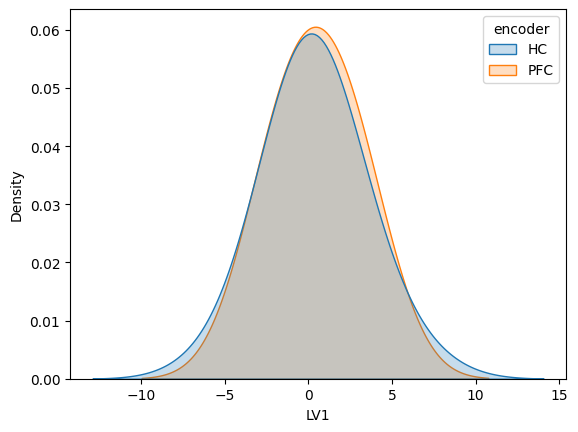

In [7]:
sns.kdeplot(data=latent_space_comb[['LV1', 'encoder']], x='LV1', hue='encoder', fill=True, bw_adjust=2)

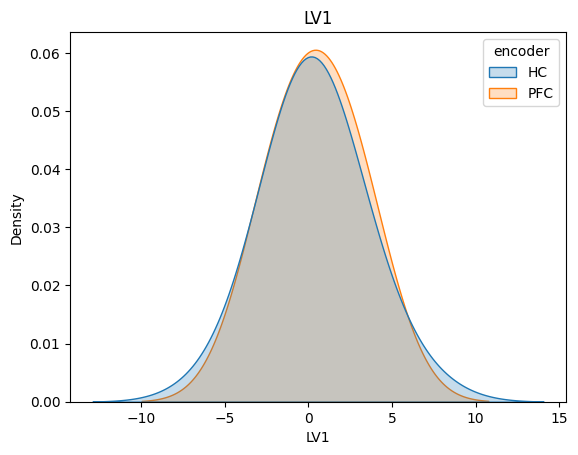

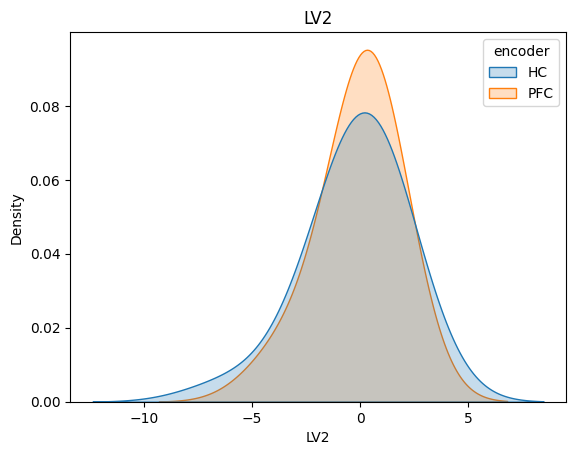

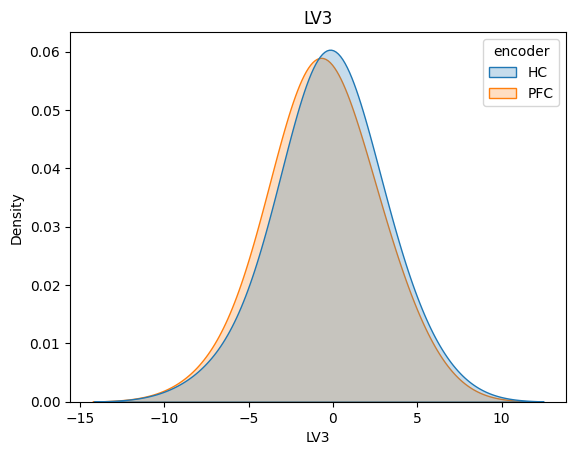

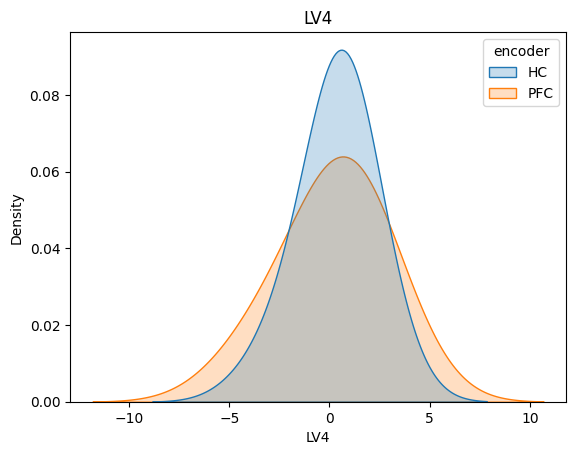

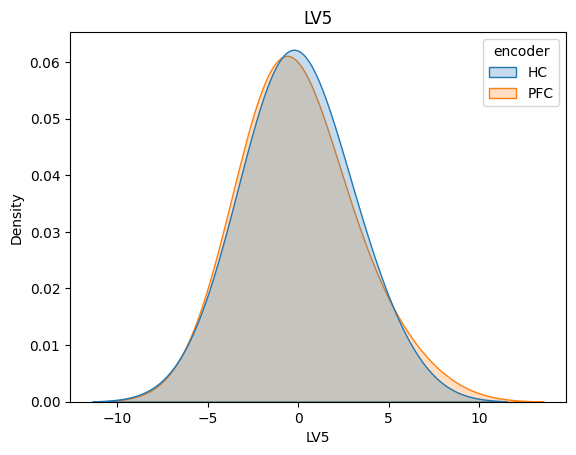

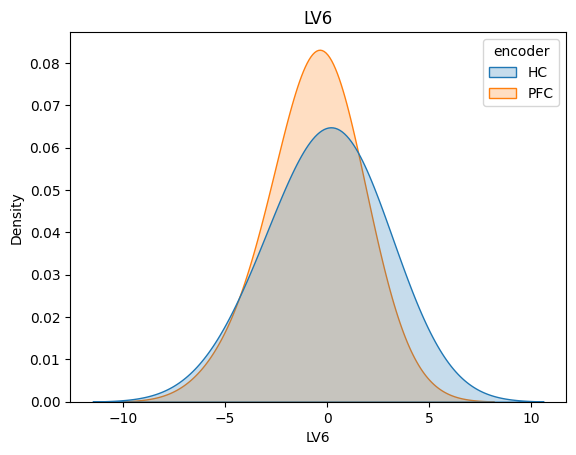

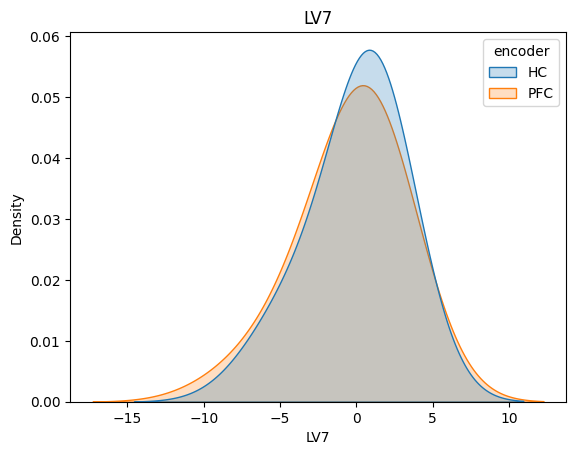

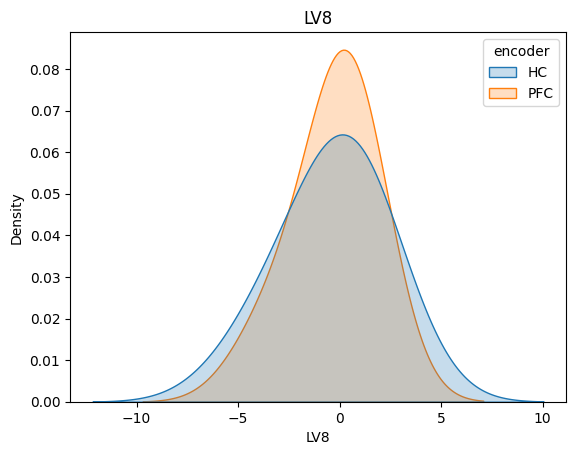

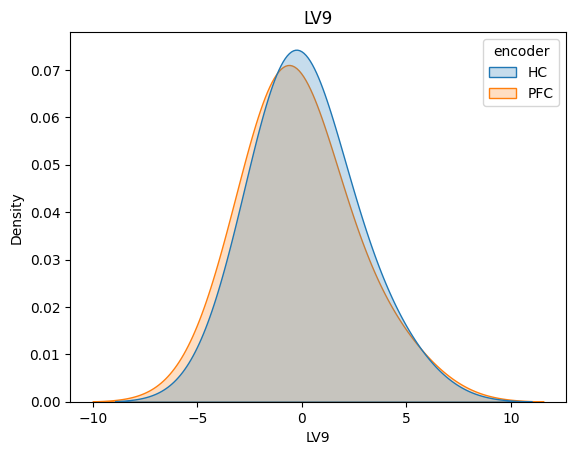

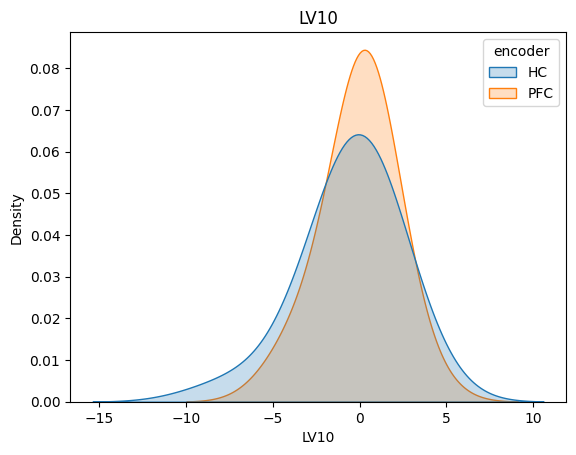

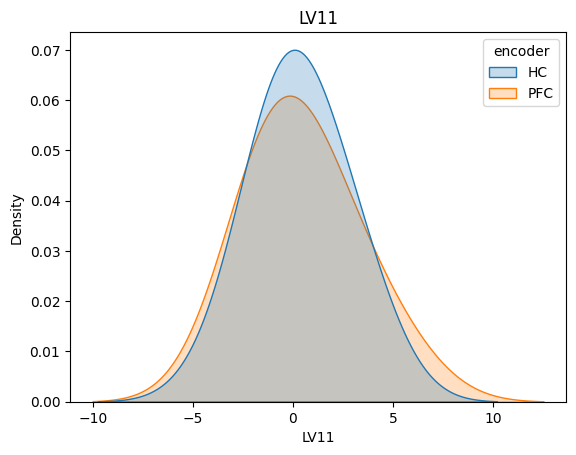

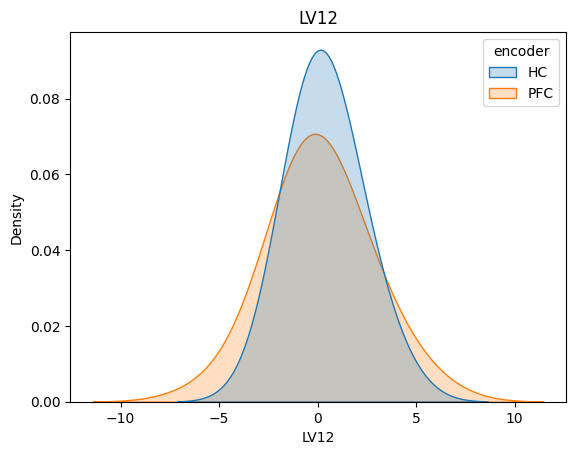

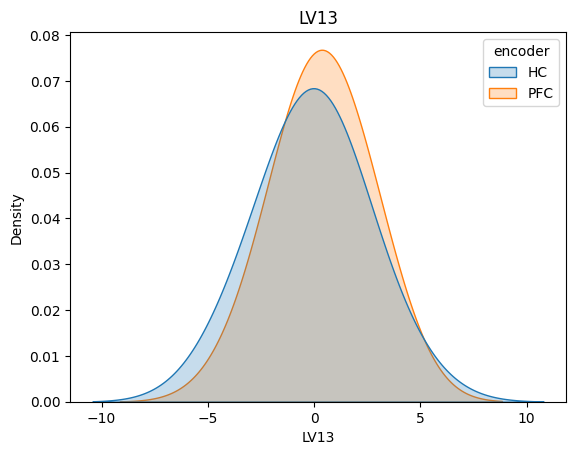

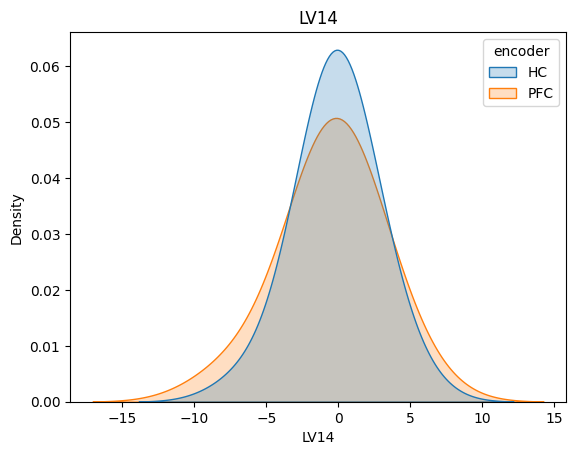

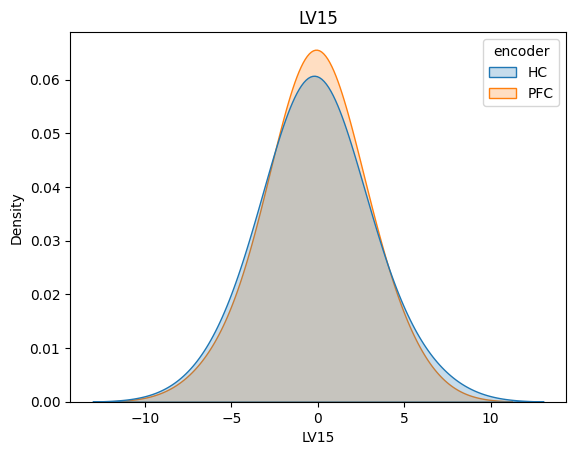

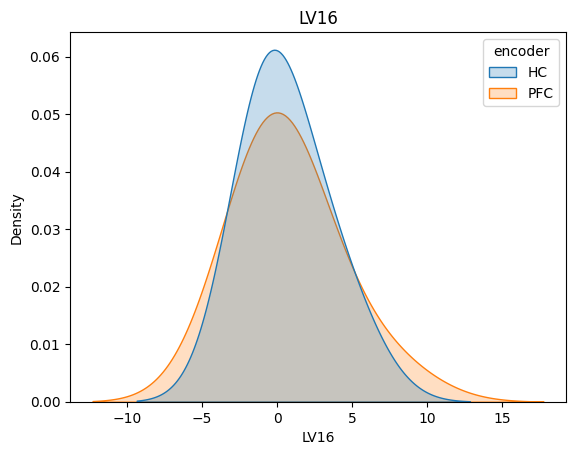

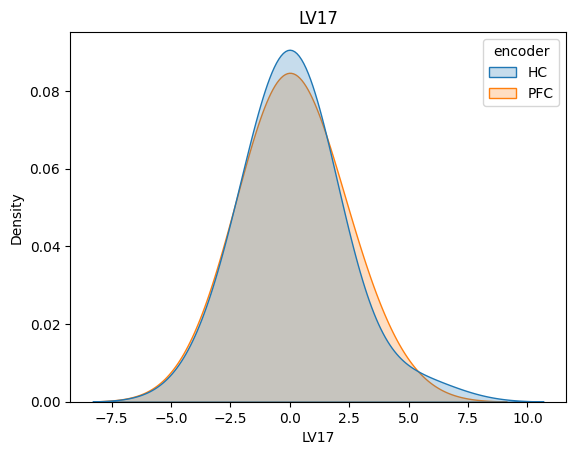

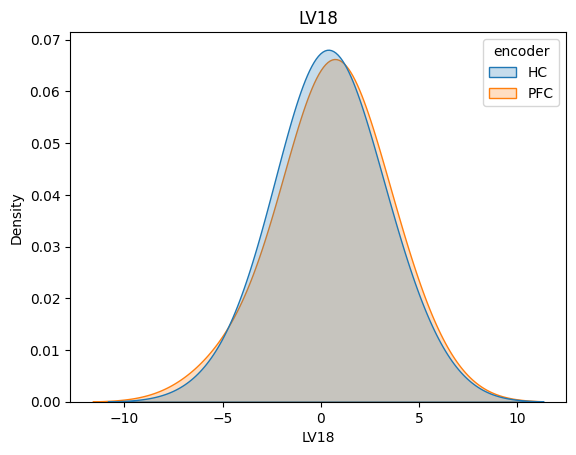

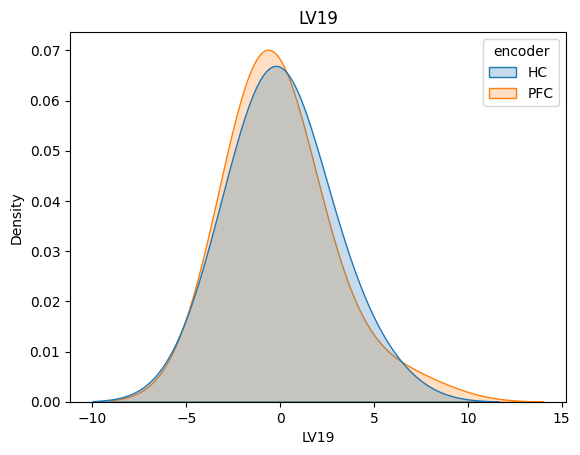

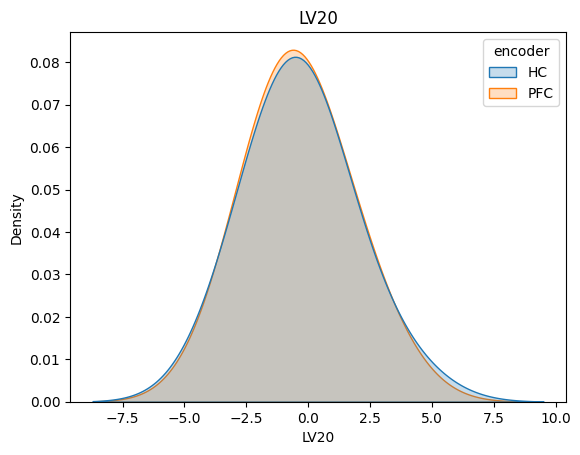

In [8]:
for column in latent_space_comb.columns[:latent_dim]:
    plt.figure()
    sns.kdeplot(data=latent_space_comb[[column, 'encoder']], x=column, hue='encoder', fill=True, bw_adjust=2)
    plt.title(column)

In [9]:
latent_space_sub = latent_space_comb.iloc[:, :latent_dim]

In [10]:
latent_space_sub

,LV1,LV2,LV3,LV4,LV5,LV6,LV7,LV8,LV9,LV10,LV11,LV12,LV13,LV14,LV15,LV16,LV17,LV18,LV19,LV20
0,0.841536,1.693594,-6.343078,-1.665026,0.126362,2.588125,1.652463,1.123457,-0.532597,-0.543050,2.719643,0.716037,-0.974171,-6.358378,-0.590681,1.007571,1.602011,-1.414319,4.815956,-1.685972
1,-0.059384,0.237056,-2.925490,2.762263,0.233917,0.148604,0.362642,-0.082269,0.258950,-0.028280,0.812524,-0.976080,0.915179,0.718462,1.733407,0.475822,-0.937782,-0.287388,-1.249303,-3.059617
2,-2.130337,0.456331,-0.139716,2.755518,-1.752198,1.643458,1.307314,1.224831,-0.050607,1.270410,-0.998691,0.683025,1.429408,1.124194,0.513547,-0.574933,-1.665270,1.265891,1.011238,-0.177303
3,1.907925,-2.668868,3.625552,-1.803548,4.282400,-1.200847,-3.689881,2.040573,0.767839,2.981288,-0.138515,-0.988238,3.051769,2.565031,1.372885,5.198873,-2.906973,4.640347,4.002024,0.327889
4,-0.543092,0.367533,-0.652702,0.816206,-0.243537,0.905739,0.779527,-1.395027,-0.260186,-0.366116,-0.955779,-0.502279,-0.571320,-0.722558,-0.107911,-1.923613,0.532540,0.108223,0.620840,-0.201557
5,0.981291,-0.350953,1.137746,1.792957,-4.138418,-2.522564,0.678475,-1.607518,3.579844,-0.426684,3.171267,0.531471,-3.809242,1.938986,-1.246720,5.430325,5.281795,3.438314,-2.446037,3.860714
6,-1.872440,-0.815204,-1.757732,-1.423024,-1.791259,0.721876,1.697282,3.031338,-2.402030,-0.286272,-2.433120,-2.274041,-0.307504,-0.885335,-0.978884,-0.129789,0.007857,1.405643,0.981081,-2.068404
7,-0.172987,0.955735,-0.039486,1.156344,-0.543814,0.024374,1.571987,-0.355378,0.379467,0.636957,-1.004237,-0.898078,0.663956,-0.765862,0.051872,-0.773645,-0.674156,-0.440792,-1.696964,-0.534462
8,-5.063306,1.271600,2.808746,0.006518,1.988176,3.745919,-4.362633,-5.161782,-1.994533,-1.198194,0.707049,0.421891,4.178031,-0.102563,-5.326414,-1.412346,-1.911514,-0.621201,-3.175793,1.337770
9,-0.956881,0.786577,0.012864,0.430783,-1.386675,-2.476841,1.672899,1.249863,-0.790347,-0.869080,-0.809318,-0.130229,-1.847976,-0.662966,-1.868323,-1.340887,0.525280,0.483562,0.670666,0.020856


In [11]:
# make umap object 
reducer = umap.UMAP(n_neighbors=50, min_dist=1, n_components=2, random_state=random_state)
embedding = reducer.fit_transform(latent_space_sub)

/home/rachel/miniforge3/envs/mm-vae/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/rachel/miniforge3/envs/mm-vae/lib/python3.12/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


In [12]:
embedding_df = pd.DataFrame(embedding, columns=['UMAP1', 'UMAP2'])
for hue in hues: 
    embedding_df[hue] = latent_space_comb[hue]

In [13]:
embedding_df

,UMAP1,UMAP2,cell_type,strain,encoder,14-6-Bin
0,44.218525,-25.736132,glut,D2,HC,1
1,43.311230,-24.346941,glut,D2,HC,1
2,46.175808,-25.484257,glut,D2,HC,1
3,43.895851,-24.850630,glut,D2,HC,1
4,45.269306,-25.584908,glut,D2,HC,1
5,43.751026,-22.349403,Inhibitory,D2,HC,1
6,43.171528,-25.407488,glut,D2,HC,1
7,45.668434,-23.085979,Oligodendrocytes,D2,HC,1
8,43.815811,-23.594488,Astrocytes,D2,HC,1
9,46.743267,-24.306063,glut,D2,HC,1


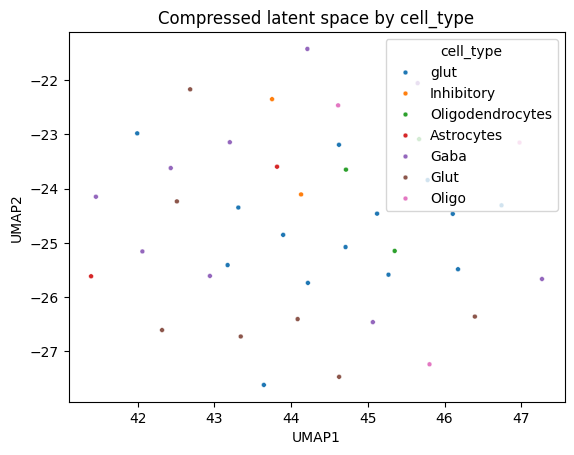

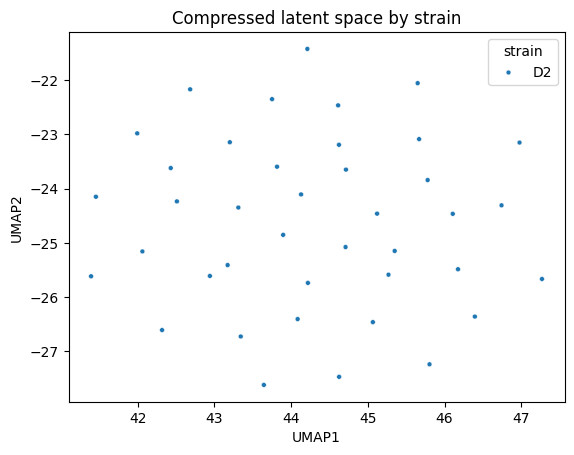

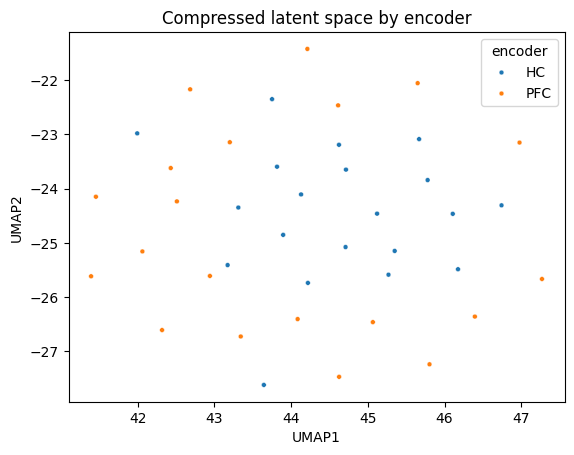

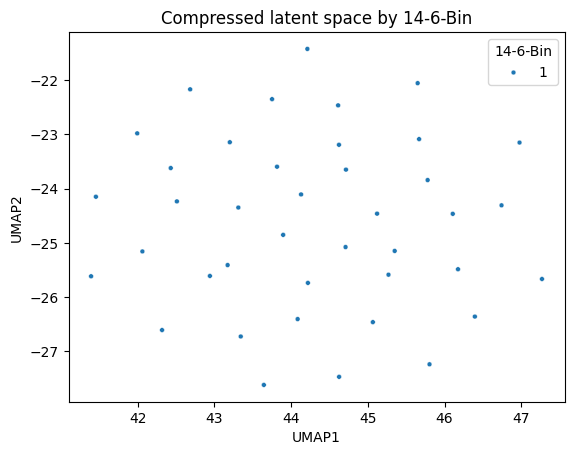

In [14]:
for hue in hues: 
    plt.figure()
    sns.scatterplot(x='UMAP1', y='UMAP2', hue=hue, data=embedding_df, s=12)
    plt.title(f'Compressed latent space by {hue}')

In [15]:
embedding_df.to_csv(os.path.join(results_folder, 'latent_umap_embeddings.csv'))